In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [23]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r
import random
import harmonypy as hm
import liana as li
# import cellphonedb method via liana
from liana.method import cellphonedb
from liana.method import rank_aggregate

# CellphoneDB

In [3]:
# load adata with cluster information 
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/clustering_batch_corrected/adata_after_cell_annotation.h5ad")

In [4]:
# set .x to normalized counts
adata

AnnData object with n_obs × n_vars = 111118 × 20681
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'soupx_groups', 'scDblFinder_score', 'scDblFinder_class', 'sample', 'condition', 'size_factors', 'leiden', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'leiden_res0_3', 'leiden_res0_4', 'leiden_res0_6', 'leiden_res0_7', 'leiden_res0_8', 'manual_celltype_annotation'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', '

In [5]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,leiden_res0_25,leiden_res0_5,leiden_res1,leiden_res2,leiden_res0_3,leiden_res0_4,leiden_res0_6,leiden_res0_7,leiden_res0_8,manual_celltype_annotation
AAACCAAAGCGCCTGA-1-S26_17,1741,7.462789,2887.0,7.968319,15.587115,21.440942,27.779702,37.062695,57.014202,28.0,...,0,0,0,0,0,0,0,0,0,fibroblasts
AAACCAAAGGCGAGAC-1-S26_17,1458,7.285507,2360.0,7.766840,14.745763,20.932203,28.093220,38.474576,59.406780,32.0,...,0,3,2,0,0,6,1,4,0,fibroblasts
AAACCAAAGGCTCCGA-1-S26_17,2520,7.832411,5668.0,8.642768,18.719125,25.723359,32.163020,40.508116,56.527876,48.0,...,3,7,9,3,6,3,5,5,4,cardiomyocytes
AAACCAAAGGTGCAGA-1-S26_17,886,6.787845,1103.0,7.006695,10.063463,17.225748,26.291931,37.805984,65.004533,16.0,...,2,9,5,6,3,4,6,7,7,cardiomyocytes
AAACCAAAGTCGCATA-1-S26_17,1109,7.012115,1730.0,7.456455,14.104046,21.502890,30.635838,42.890173,64.797688,32.0,...,4,4,15,11,1,12,3,12,11,endothel cells
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTAGCCCA-1-S26_32,755,6.628041,1182.0,7.075809,14.720812,24.619289,35.109983,52.030457,78.426396,7.0,...,4,4,13,18,1,12,12,12,11,endothel cells
TGTGTTAGTAGGTCCC-1-S26_32,2209,7.700748,4861.0,8.489205,16.251800,22.197079,29.129809,38.407735,55.996708,38.0,...,0,0,0,2,0,0,0,0,0,fibroblasts
TGTGTTAGTATGTCCG-1-S26_32,1395,7.241366,2239.0,7.714231,9.870478,16.971862,25.279142,37.114783,60.026798,37.0,...,4,4,16,13,1,12,3,12,11,endothel cells
TGTGTTAGTTAACCCG-1-S26_32,721,6.582025,1021.0,6.929517,14.397649,24.191969,34.769833,48.971596,78.354554,21.0,...,2,9,5,8,3,4,6,7,7,cardiomyocytes


In [8]:
adata.obs["condition"].cat.categories

Index(['IRI_LNP_circGFP', 'IRI_LNP_circINSR', 'Sham_LNP_circGFP'], dtype='object')

In [10]:
adata.layers

Layers with keys: analytic_pearson_residuals, counts, log1p_norm, scran_normalization, soupX_counts

In [11]:
adata.X = adata.layers["scran_normalization"]

## Subsetting for condition of interest

### 1. IRI_LNP_circINSR

In [12]:
# subset for condition of interest: IRIcircINSR
adata_insr = adata[adata.obs["condition"] == "IRI_LNP_circINSR"].copy()

In [16]:
li.rs.show_resources()

['baccin2019',
 'cellcall',
 'cellchatdb',
 'cellinker',
 'cellphonedb',
 'celltalkdb',
 'connectomedb2020',
 'consensus',
 'embrace',
 'guide2pharma',
 'hpmr',
 'icellnet',
 'italk',
 'kirouac2010',
 'lrdb',
 'mouseconsensus',
 'ramilowski2015']

In [17]:
cellphonedb(
    adata_insr, groupby="manual_celltype_annotation", use_raw=False, return_all_lrs=True, verbose=True, resource_name = "mouseconsensus"
)

Using resource `mouseconsensus`.
Using `.X`!
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1598 features of mat are empty, they will be removed.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.25 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 32283 samples and 1138 features


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [18]:
adata_insr.uns["liana_res"].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lrs_to_keep,lr_means,cellphone_pvals
130945,Dcn,Dcn,2.072192,0.885135,Egfr,Egfr,1.909081,0.582418,mesothelial_epithelial cells,neuronal cells,True,1.990637,0.0
131057,Vcan,Vcan,1.797556,0.804054,Egfr,Egfr,1.909081,0.582418,mesothelial_epithelial cells,neuronal cells,True,1.853319,0.0
91781,Cxcl10,Cxcl10,2.145998,0.952703,Sdc4,Sdc4,1.495166,0.864865,mesothelial_epithelial cells,mesothelial_epithelial cells,True,1.820582,0.0
126063,Vcan,Vcan,1.675864,0.914207,Egfr,Egfr,1.909081,0.582418,fibroblasts,neuronal cells,True,1.792473,0.0
121418,Fgf13,Fgf13,1.610815,0.558652,Egfr,Egfr,1.909081,0.582418,cardiomyocytes,neuronal cells,True,1.759948,0.0


In [50]:
adata_insr.uns["liana_res"].to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor.csv",
    index=True
)

source is the header thingy, and the target is on the x-axis

In [59]:
fig = li.pl.dotplot(
    adata=adata_insr,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    # since cpdbv2 suggests using a filter to FPs
    # we can filter the interactions according to p-values <= 0.01
    filter_fun=lambda x: x["cellphone_pvals"] <= 0.01,
    # as this type of methods tends to result in large numbers
    # of predictions, we can also further order according to expression magnitude
    orderby="lr_means",
    orderby_ascending=False,  # we want to prioritize those with highest expression
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(9, 5),
    size_range=(1, 6),
)

fig.save("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor_TOP20_cardiomyocyte_myeloid_cells_lymphoid_cells_plot.png", bbox_inches="tight", dpi=300)

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 9 x 5 in image.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor_TOP20_cardiomyocyte_myeloid_cells_lymphoid_cells_plot.png


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


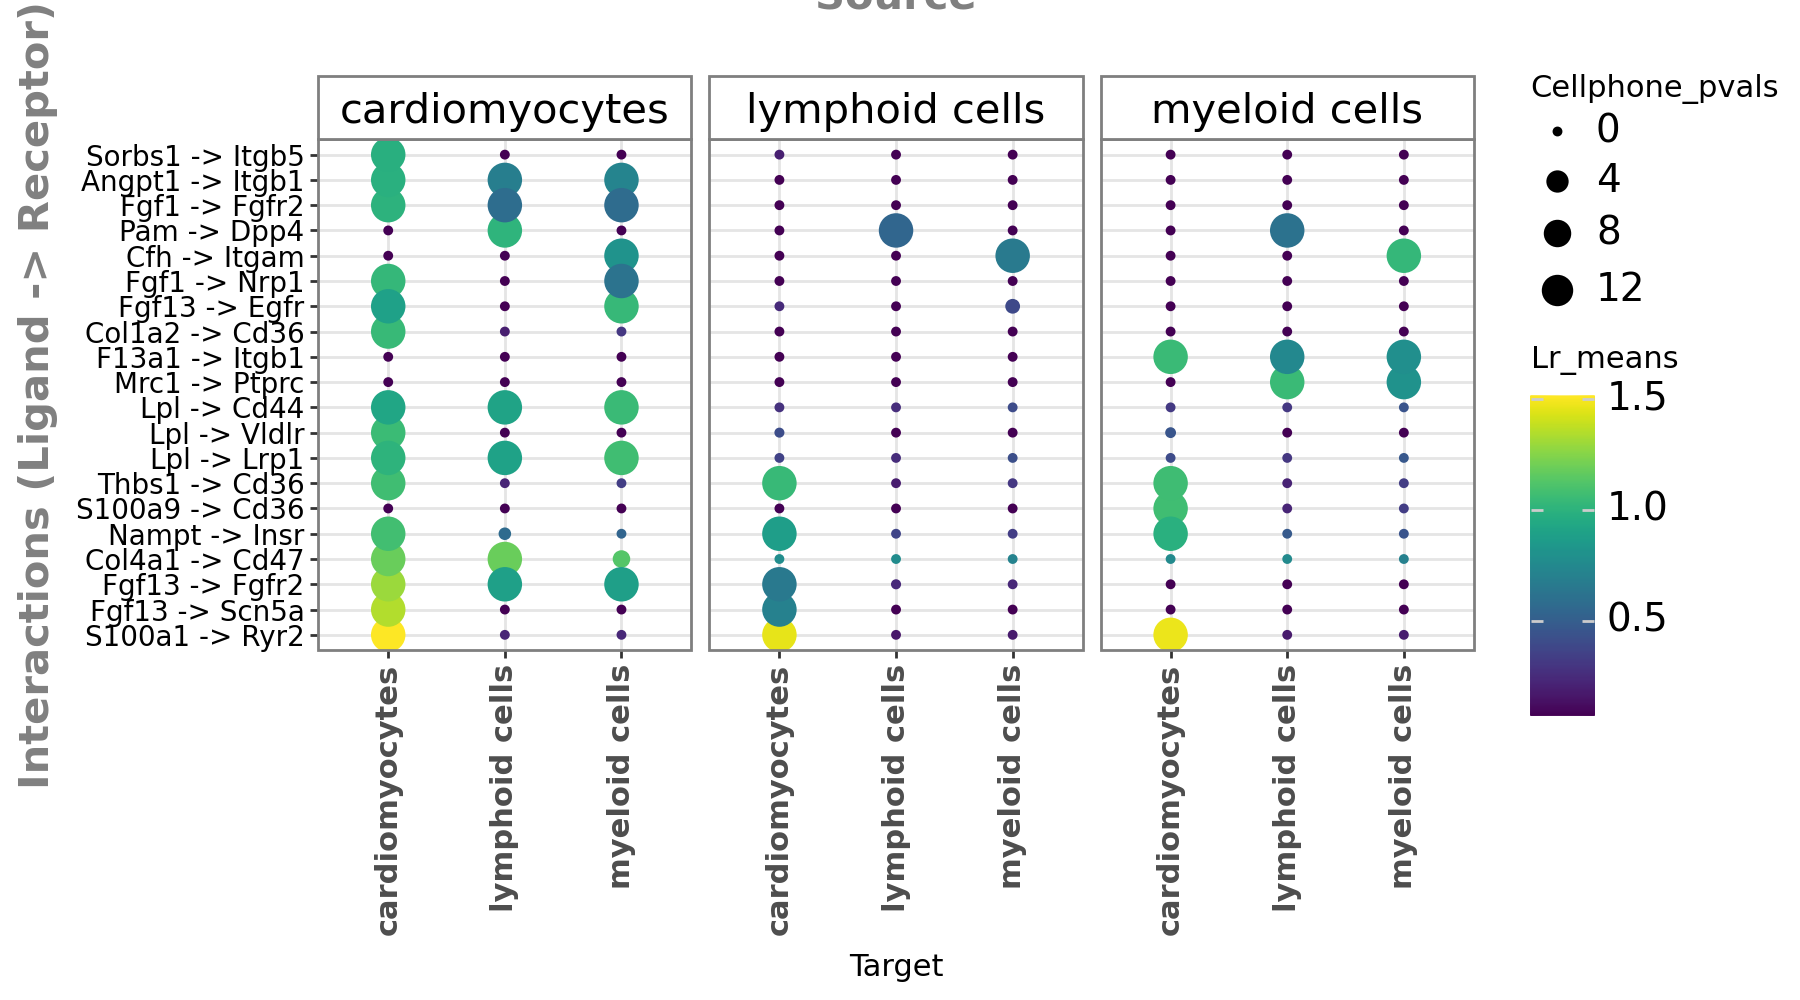

In [22]:
li.pl.dotplot(
    adata=adata_insr,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    # since cpdbv2 suggests using a filter to FPs
    # we can filter the interactions according to p-values <= 0.01
    filter_fun=lambda x: x["cellphone_pvals"] <= 0.01,
    # as this type of methods tends to result in large numbers
    # of predictions, we can also further order according to expression magnitude
    orderby="lr_means",
    orderby_ascending=False,  # we want to prioritize those with highest expression
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(9, 5),
    size_range=(1, 6),
)

zu cellphone wichtig: zeigt nur interaktionen die basierend auf der mrna expression theoretisch möglich wären, heißt aber nicht, dass die interaktion tatsächlich stattfindet. wir bräuchten eigentlich noch spatial um räumliche anordnung besser zu verstehen und zu gucken, ob interaktion überhaupt möglich wäre, auch ist alles nur mrna ebene -> vllt wird protein gar nicht translatiert undnur mrna exprimiert? 


In [24]:
rank_aggregate(
    adata_insr, groupby="manual_celltype_annotation", return_all_lrs=True, use_raw=False, verbose=True, resource_name = "mouseconsensus"
)

Using resource `mouseconsensus`.
Using `.X`!
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1598 features of mat are empty, they will be removed.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.25 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 32283 samples and 1138 features


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


...

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


Running NATMI


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


Running SingleCellSignalR


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


## Aggregated methods

In [25]:
adata_insr.uns["liana_res"].drop_duplicates(
    ["ligand_complex", "receptor_complex"]
).head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
95662,mesothelial_epithelial cells,neuronal cells,Dcn,Egfr,1.990637,0.0,3.955983,1.584804,2.857437,0.108537,0.954953,5.342434e-05,1.124708e-09
97170,mesothelial_epithelial cells,neuronal cells,Vcan,Egfr,1.853319,0.0,3.431682,1.446419,2.721270,0.108594,0.951794,5.342434e-05,4.498798e-09
90642,mesothelial_epithelial cells,mesothelial_epithelial cells,Cxcl10,Sdc4,1.820582,0.0,3.208624,1.868354,2.184878,0.112755,0.950228,5.342434e-05,1.012222e-08
15964,cardiomyocytes,neuronal cells,Fgf13,Egfr,1.759948,0.0,3.075178,1.617567,3.923126,0.285089,0.949214,5.342434e-05,2.811686e-08
136526,neuronal cells,neuronal cells,Nrg4,Egfr,1.683639,0.0,2.783815,4.613293,3.473821,0.335312,0.946760,5.161980e-07,5.510822e-08


In [52]:
adata_insr.uns["liana_res"].drop_duplicates(
    ["ligand_complex", "receptor_complex"]).to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor_aggregated_methods.csv",
    index=True
)

In [60]:
fig = li.pl.dotplot(
    adata=adata_insr,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,  # we inverse sign since we want small p-values to have large sizes
    inverse_size=True,
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    # since the rank_aggregate can also be interpreted as a probability distribution
    # we can again filter them according to their specificity significance
    # yet here the interactions are filtered according to
    # how consistently highly-ranked is their specificity across the methods
    # filterby="specificity_rank",
    # filter_lambda=lambda x: x <= 0.05,
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    # again, we can also further order according to magnitude
    orderby="magnitude_rank",
    orderby_ascending=True,  # prioritize those with lowest values
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(15, 8),
    size_range=(1, 6),
)
fig.save("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor_TOP40_cardiomyocyte_myeloid_cells_lymphoid_cells_fibroblast_endothel_cells_aggregated_methods_plot.png")

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 15 x 8 in image.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circINSR_Ligand_Receptor_TOP40_cardiomyocyte_myeloid_cells_lymphoid_cells_fibroblast_endothel_cells_aggregated_methods_plot.png


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


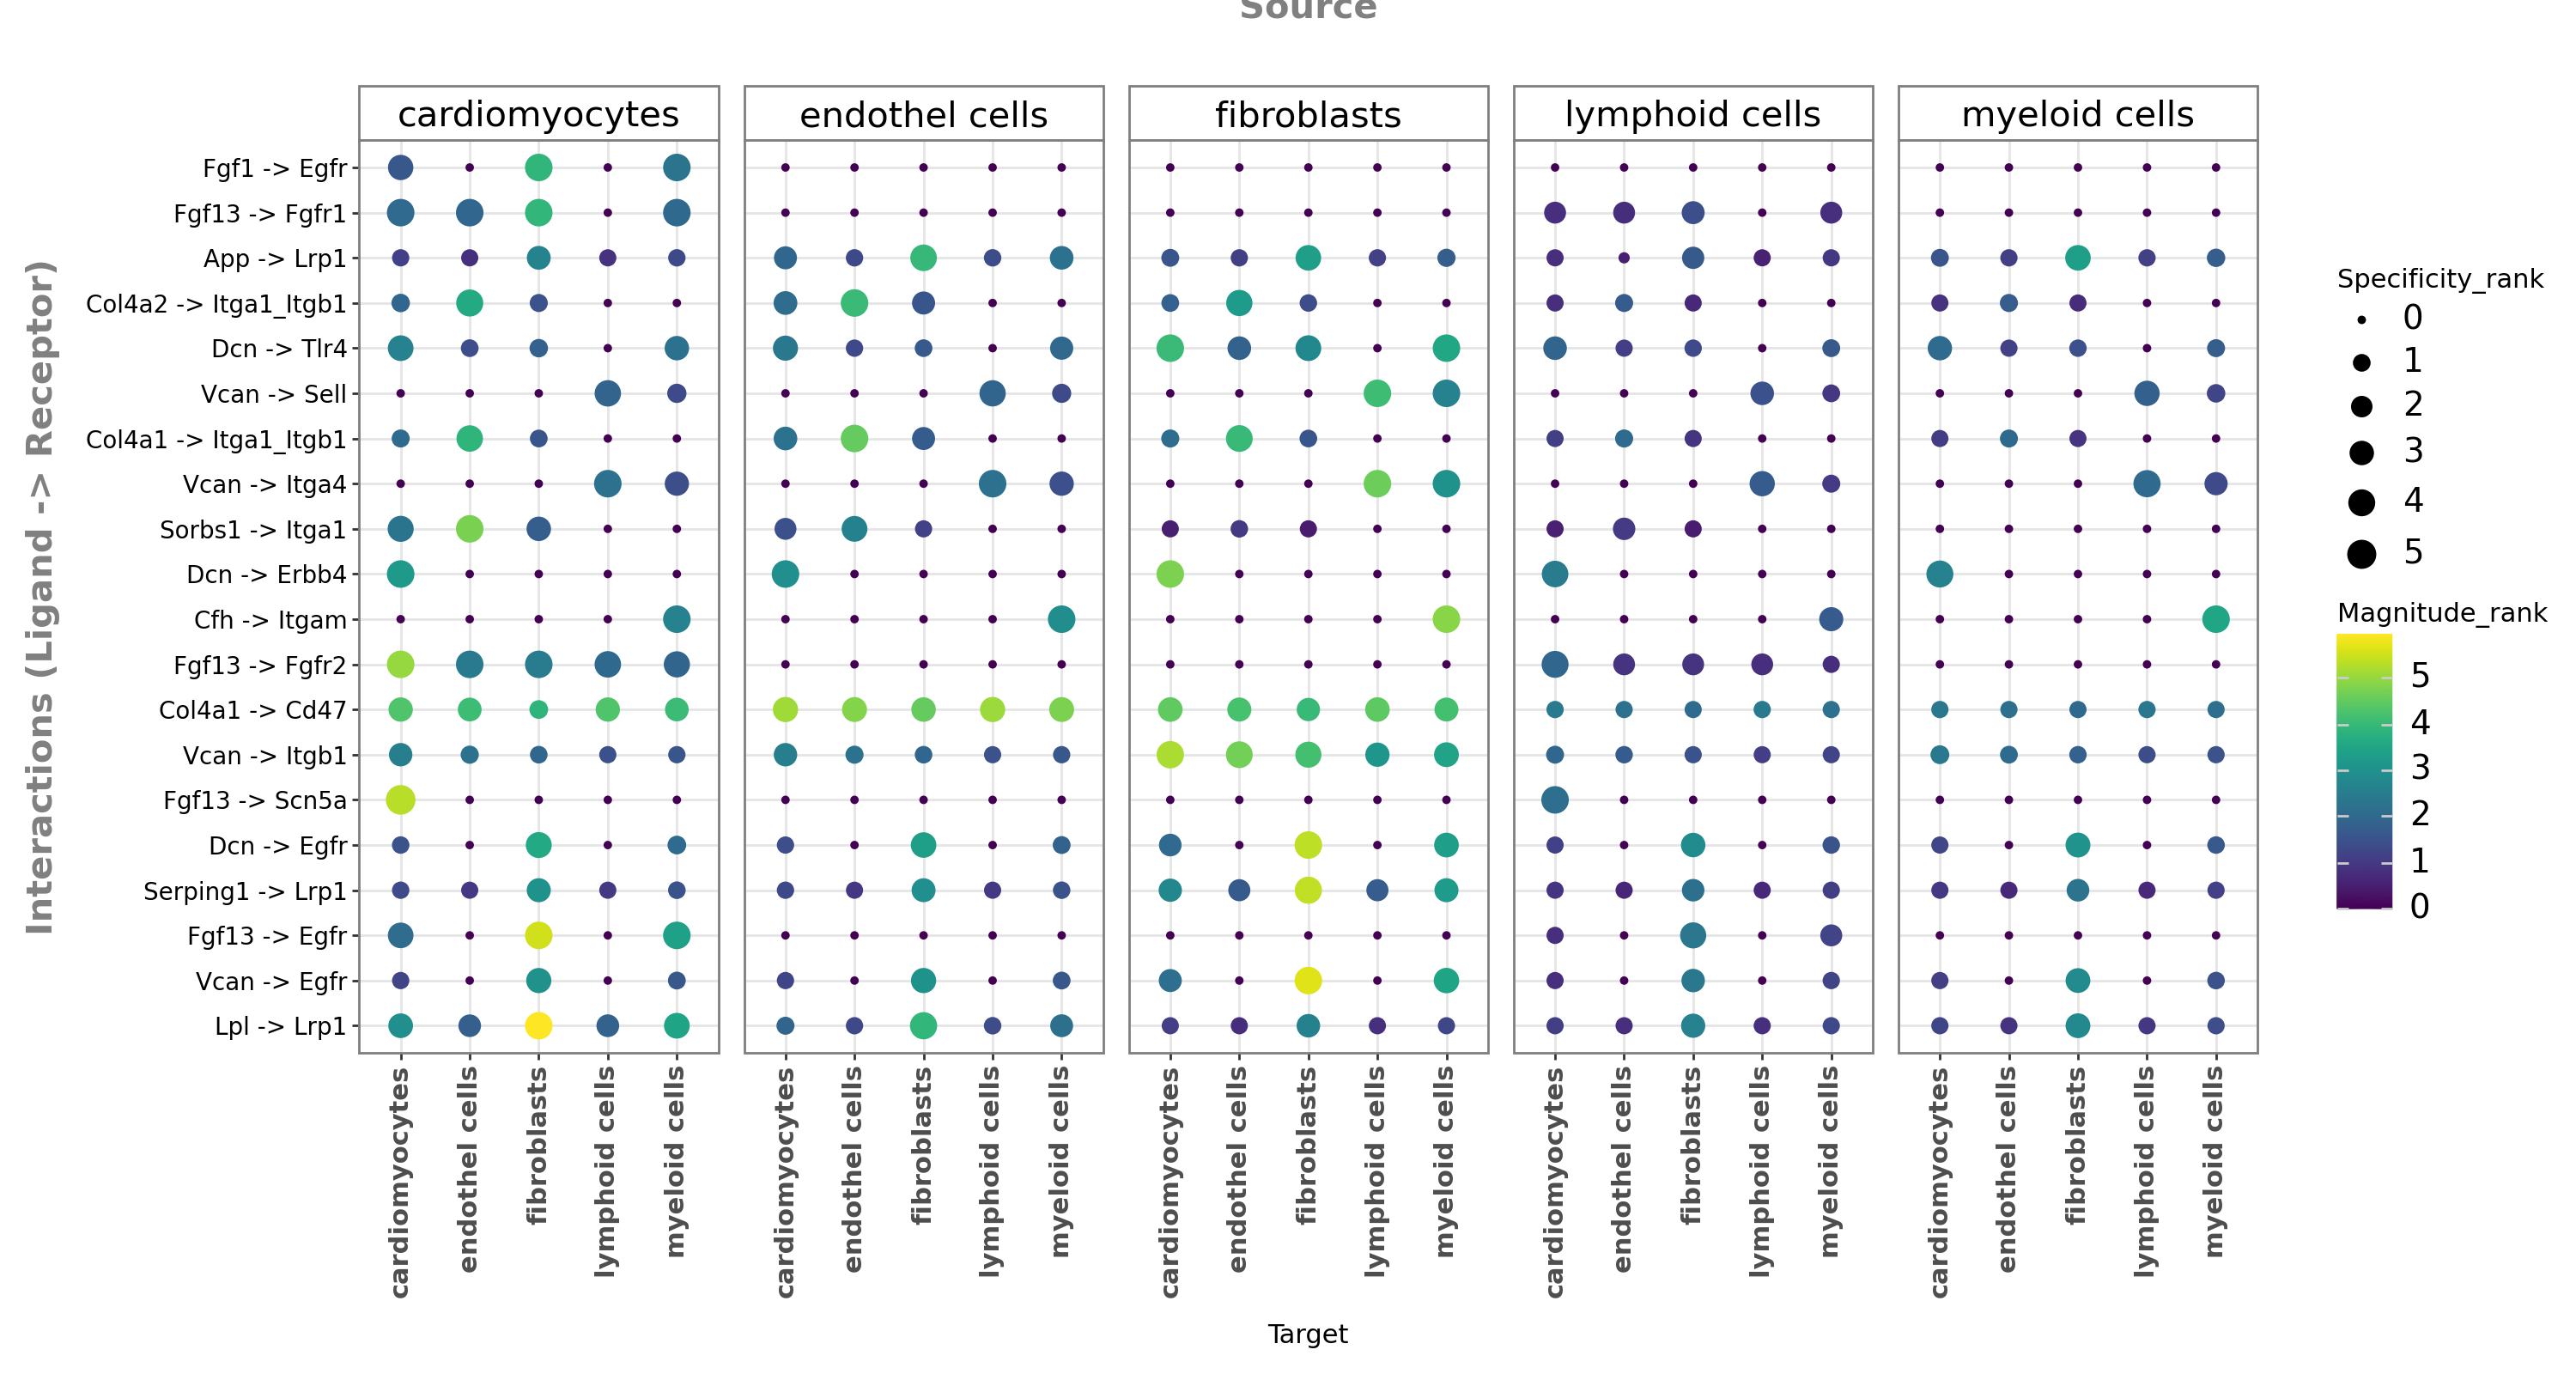

In [27]:
li.pl.dotplot(
    adata=adata_insr,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,  # we inverse sign since we want small p-values to have large sizes
    inverse_size=True,
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    # since the rank_aggregate can also be interpreted as a probability distribution
    # we can again filter them according to their specificity significance
    # yet here the interactions are filtered according to
    # how consistently highly-ranked is their specificity across the methods
    # filterby="specificity_rank",
    # filter_lambda=lambda x: x <= 0.05,
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    # again, we can also further order according to magnitude
    orderby="magnitude_rank",
    orderby_ascending=True,  # prioritize those with lowest values
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(15, 8),
    size_range=(1, 6),
)

### 2. IRI_LNP_circGFP

In [28]:
adata_gfp = adata[adata.obs["condition"] == "IRI_LNP_circGFP"].copy()

In [29]:
cellphonedb(
    adata_gfp, groupby="manual_celltype_annotation", use_raw=False, return_all_lrs=True, verbose=True, resource_name = "mouseconsensus"
)

Using resource `mouseconsensus`.
Using `.X`!
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
952 features of mat are empty, they will be removed.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.24 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 33536 samples and 1153 features


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [41]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) & (adata_insr.uns["liana_res"]["lr_means"] > 1)]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
95662,mesothelial_epithelial cells,neuronal cells,Dcn,Egfr,1.990637,0.0,3.955983,1.584804,2.857437,0.108537,0.954953,0.000053,1.124708e-09
97170,mesothelial_epithelial cells,neuronal cells,Vcan,Egfr,1.853319,0.0,3.431682,1.446419,2.721270,0.108594,0.951794,0.000053,4.498798e-09
90642,mesothelial_epithelial cells,mesothelial_epithelial cells,Cxcl10,Sdc4,1.820582,0.0,3.208624,1.868354,2.184878,0.112755,0.950228,0.000053,1.012222e-08
57218,fibroblasts,neuronal cells,Vcan,Egfr,1.792473,0.0,3.199361,1.379790,2.591213,0.101242,0.950160,0.000053,1.799492e-08
15964,cardiomyocytes,neuronal cells,Fgf13,Egfr,1.759948,0.0,3.075178,1.617567,3.923126,0.285089,0.949214,0.000053,2.811686e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96440,mesothelial_epithelial cells,neuronal cells,Lrig1,Egfr,1.001349,0.0,0.178720,1.000656,1.839893,0.051187,0.818373,0.000053,2.386466e-02
96062,mesothelial_epithelial cells,neuronal cells,Gstp1,Egfr,1.001267,0.0,0.178409,1.654984,1.896010,0.227029,0.818244,0.000053,2.394469e-02
116418,myeloid cells,neuronal cells,Lrig2,Egfr,1.000380,0.0,0.175022,0.821097,1.704895,0.018077,0.816814,0.000981,2.492520e-02
82068,mesothelial_epithelial cells,cardiomyocytes,Thbs2,Cd36,1.029769,0.0,0.167616,0.595678,1.193207,0.146334,0.813557,0.000053,2.712326e-02


In [54]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) & (adata_insr.uns["liana_res"]["lr_means"] > 1)].to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circGFP_Ligand_Receptor_filtered_p_value_0_01_lr_means_1.csv",
    index=True
)

### Try different filter

p-value>0.01 & target myeloid cells

In [42]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) & (adata_insr.uns["liana_res"]["target"]== "myeloid cells")]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
132750,neuronal cells,myeloid cells,Cfh,Itgam,1.518619,0.000,2.181211,1.458422,2.032510,0.183147,0.940266,5.342434e-05,4.959223e-07
92798,mesothelial_epithelial cells,myeloid cells,Cfh,Itgam,1.335428,0.000,1.754349,1.277711,1.439213,0.147305,0.933849,5.342434e-05,6.155550e-06
133304,neuronal cells,myeloid cells,Fgb,Itgam,1.333000,0.000,1.748691,5.390463,2.909824,0.737883,0.933749,7.237134e-08,6.322993e-06
92679,mesothelial_epithelial cells,myeloid cells,C3,Itgam,1.328547,0.000,1.738315,2.443399,2.581259,0.334626,0.933565,1.456144e-05,6.838796e-06
133295,neuronal cells,myeloid cells,Fga,Itgam,1.298834,0.000,1.669079,5.939551,2.832216,0.745656,0.932294,1.903349e-09,1.101521e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53999,fibroblasts,myeloid cells,Lrpap1,Sorl1,0.118465,0.000,0.011929,0.247485,0.132838,0.013494,0.537912,1.850957e-03,3.329850e-01
132475,neuronal cells,myeloid cells,Apoa2,Ldlr,0.110887,0.000,0.012139,0.931345,0.158987,0.074646,0.540083,3.521561e-04,3.335471e-01
54265,fibroblasts,myeloid cells,Ptgs2,Alox5,0.104366,0.000,0.010743,0.359648,0.086463,0.086142,0.524876,6.266862e-04,3.394886e-01
54151,fibroblasts,myeloid cells,Ntng2,Lrrc4,0.100696,0.003,0.009929,0.046917,0.021168,0.013613,0.515039,1.820671e-03,3.425921e-01


p-value>0.01 & source myeloid cells

In [43]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) & (adata_insr.uns["liana_res"]["source"]== "myeloid cells")]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
111176,myeloid cells,mesothelial_epithelial cells,Il15ra,Axl,1.189464,0.000,1.281508,0.919804,0.931035,0.063179,0.923463,0.000053,0.000048
115638,myeloid cells,neuronal cells,Dcn,Egfr,1.270573,0.000,1.206664,0.737687,1.342999,0.033106,0.921309,0.000166,0.000053
110776,myeloid cells,mesothelial_epithelial cells,F13a1,Itgb1,1.160738,0.000,1.344999,1.204545,1.570085,0.183371,0.925154,0.000053,0.000069
110618,myeloid cells,mesothelial_epithelial cells,Cxcl10,Sdc4,1.124272,0.000,1.126425,1.037832,0.930381,0.039584,0.918778,0.000090,0.000099
117146,myeloid cells,neuronal cells,Vcan,Egfr,1.220899,0.000,1.017001,0.753911,1.356052,0.032182,0.914882,0.000184,0.000127
...,...,...,...,...,...,...,...,...,...,...,...,...,...
103186,myeloid cells,endothel cells,Edn1,Ednrb,0.106851,0.000,0.011285,0.186636,0.104321,0.059394,0.531008,0.000573,0.337094
119022,myeloid cells,pericytes,Nppa,Npr3,0.106664,0.002,0.010851,0.035167,-0.034994,0.025566,0.526118,0.001700,0.337958
100239,myeloid cells,cardiomyocytes,Ccl5,Ccrl2,0.104678,0.000,0.010935,0.160606,0.134192,0.041107,0.527082,0.000706,0.339089
116857,myeloid cells,neuronal cells,Sema4a,Plxnb2,0.100348,0.000,0.009788,0.503513,0.157706,0.045330,0.513256,0.000355,0.342893


p-value>0.01 & source myeloid cells & target lymphoid cells

In [44]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) & 
                            (adata_insr.uns["liana_res"]["source"]== "myeloid cells") & 
                            (adata_insr.uns["liana_res"]["target"]== "lymphoid cells")]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
108995,myeloid cells,lymphoid cells,Mrc1,Ptprc,1.050987,0.000,1.040885,2.076904,1.904520,0.488526,0.915782,0.000036,0.000235
108277,myeloid cells,lymphoid cells,F13a1,Itga4,0.967516,0.000,0.915026,2.143134,2.023725,0.556415,0.910677,0.000032,0.000570
108119,myeloid cells,lymphoid cells,Cxcl10,Dpp4,0.863164,0.000,0.732998,1.913509,0.748380,0.057327,0.901235,0.000053,0.001560
108279,myeloid cells,lymphoid cells,F13a1,Itgb1,0.746476,0.000,0.423149,0.595774,0.917289,0.057690,0.873947,0.000053,0.004777
109656,myeloid cells,lymphoid cells,Vcan,Itga4,0.677554,0.000,0.438102,1.089048,0.340953,0.051407,0.875847,0.000075,0.009185
109410,myeloid cells,lymphoid cells,Sirpa,Cd47,0.660104,0.000,0.294221,0.478078,0.294498,0.046759,0.852534,0.000114,0.010589
107755,myeloid cells,lymphoid cells,Cd38,Pecam1,0.623361,0.000,0.360967,0.598408,0.466448,0.124418,0.864929,0.000053,0.013938
109098,myeloid cells,lymphoid cells,Pam,Dpp4,0.618310,0.000,0.256539,1.731445,0.452592,0.029386,0.843710,0.000249,0.014474
109658,myeloid cells,lymphoid cells,Vcan,Sell,0.602119,0.000,0.357731,1.010273,0.125659,0.053776,0.864402,0.000465,0.016127
107575,myeloid cells,lymphoid cells,B2m,Cd247,0.601849,0.000,0.316256,1.370522,0.397076,0.109098,0.857017,0.000053,0.016168


p-value>0.01 & source myeloid cells oder pericytes & target lymphoid cells

In [48]:
adata_insr.uns["liana_res"][(adata_insr.uns["liana_res"]["cellphone_pvals"] < 0.01) &
                     ((adata_insr.uns["liana_res"]["source"]== "myeloid cells") |
                     (adata_insr.uns["liana_res"]["source"]== "pericytes")) &
                       (adata_insr.uns["liana_res"]["target"]== "lymphoid cells")]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
147876,pericytes,lymphoid cells,Col4a1,Cd47,1.167109,0.002,1.345030,0.070983,-0.052175,0.018921,0.925155,0.001664,0.000063
108995,myeloid cells,lymphoid cells,Mrc1,Ptprc,1.050987,0.000,1.040885,2.076904,1.904520,0.488526,0.915782,0.000036,0.000235
108277,myeloid cells,lymphoid cells,F13a1,Itga4,0.967516,0.000,0.915026,2.143134,2.023725,0.556415,0.910677,0.000032,0.000570
108119,myeloid cells,lymphoid cells,Cxcl10,Dpp4,0.863164,0.000,0.732998,1.913509,0.748380,0.057327,0.901235,0.000053,0.001560
148754,pericytes,lymphoid cells,Lama2,Rpsa,0.842554,0.000,0.488231,0.298773,0.228188,0.027527,0.881618,0.000301,0.001903
...,...,...,...,...,...,...,...,...,...,...,...,...,...
147924,pericytes,lymphoid cells,Col4a4,Itgb3,0.141364,0.000,0.016480,0.162363,0.079806,0.030434,0.577746,0.000697,0.305978
107757,myeloid cells,lymphoid cells,Cd48,Cd2,0.132914,0.000,0.017653,1.634835,0.277098,0.471793,0.586107,0.000132,0.306233
148865,pericytes,lymphoid cells,Lin7c,Abca1,0.141899,0.007,0.015632,0.039988,0.012563,0.008737,0.571287,0.003570,0.311170
148366,pericytes,lymphoid cells,Fn1,Cd79a,0.128340,0.000,0.016126,1.142537,0.159507,0.052762,0.575093,0.000352,0.312844


In [61]:
fig = li.pl.dotplot(
    adata=adata_gfp,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    # since cpdbv2 suggests using a filter to FPs
    # we can filter the interactions according to p-values <= 0.01
    filter_fun=lambda x: x["cellphone_pvals"] <= 0.01,
    # as this type of methods tends to result in large numbers
    # of predictions, we can also further order according to expression magnitude
    orderby="lr_means",
    orderby_ascending=False,  # we want to prioritize those with highest expression
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(9, 5),
    size_range=(1, 6),
)

fig.save("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_GFP_Ligand_Receptor_TOP20_cardiomyocyte_myeloid_cells_lymphoid_cells_plot.png")

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 9 x 5 in image.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_GFP_Ligand_Receptor_TOP20_cardiomyocyte_myeloid_cells_lymphoid_cells_plot.png


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


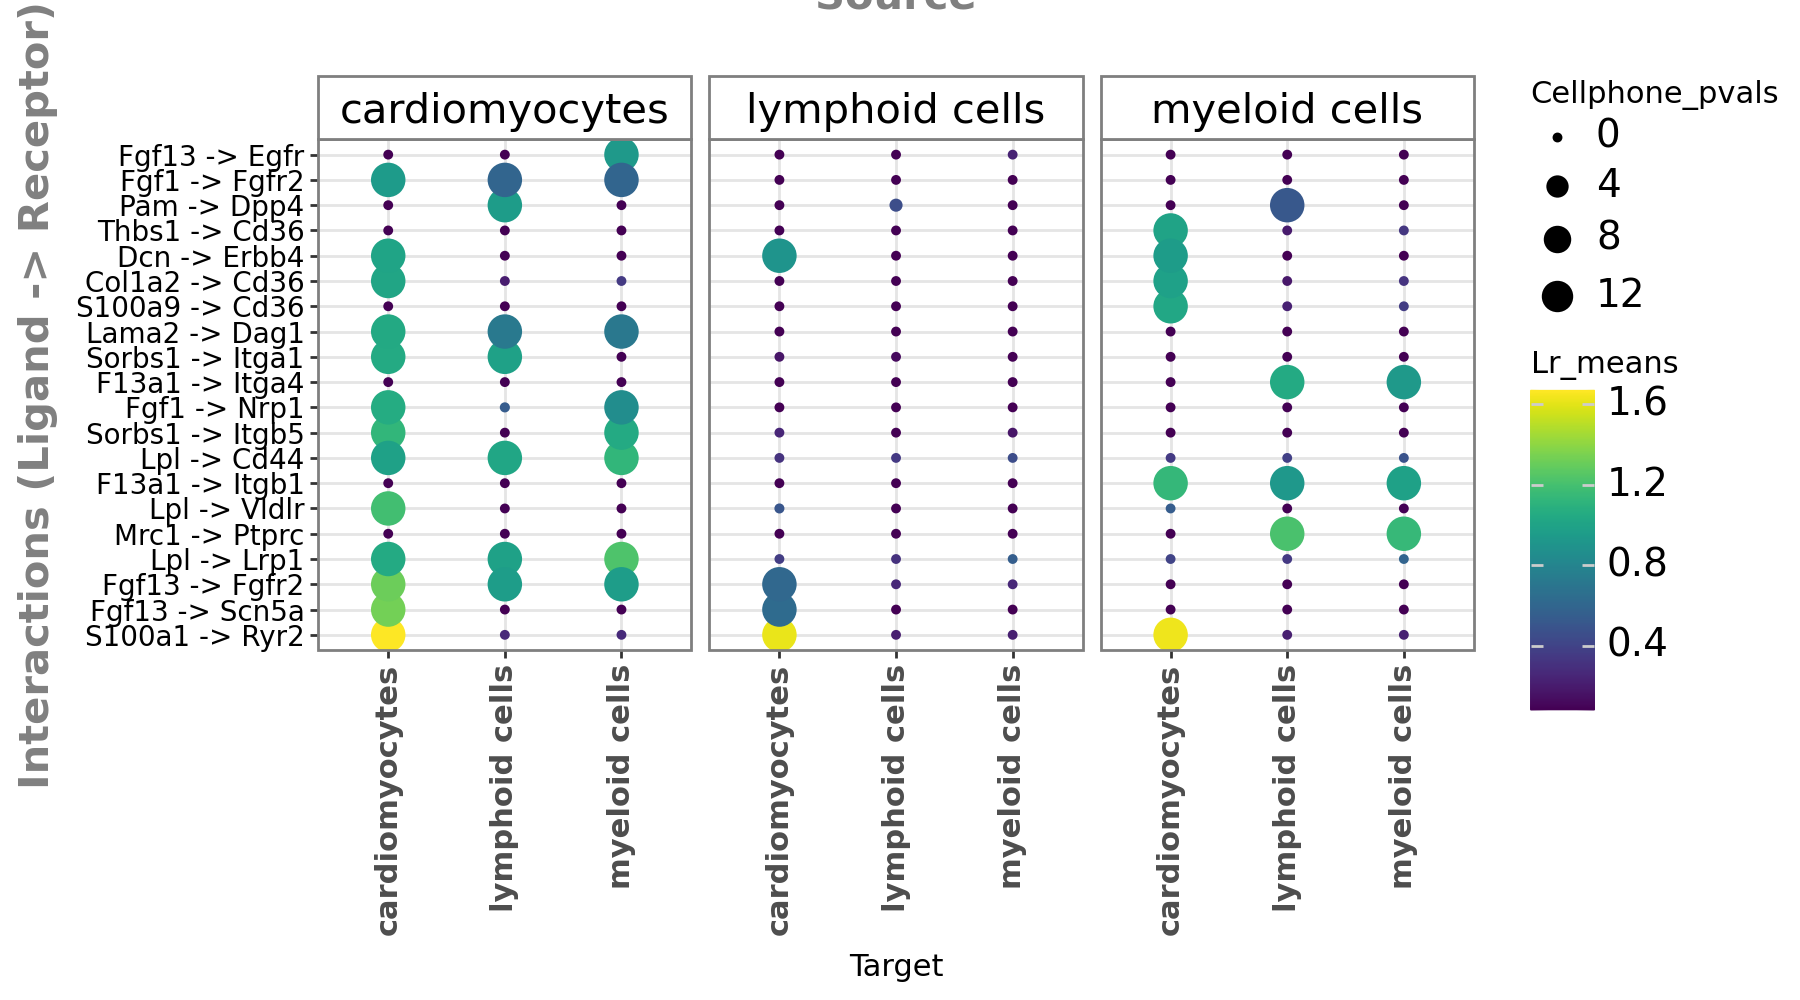

In [30]:
li.pl.dotplot(
    adata=adata_gfp,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,  # we inverse sign since we want small p-values to have large sizes
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells"],
    # since cpdbv2 suggests using a filter to FPs
    # we can filter the interactions according to p-values <= 0.01
    filter_fun=lambda x: x["cellphone_pvals"] <= 0.01,
    # as this type of methods tends to result in large numbers
    # of predictions, we can also further order according to expression magnitude
    orderby="lr_means",
    orderby_ascending=False,  # we want to prioritize those with highest expression
    top_n=20,  # and we want to keep only the top 20 interactions
    figure_size=(9, 5),
    size_range=(1, 6),
)

## aggregated methods

In [31]:
rank_aggregate(
    adata_gfp, groupby="manual_celltype_annotation", return_all_lrs=True, use_raw=False, verbose=True, resource_name = "mouseconsensus"
)
adata_gfp.uns["liana_res"].drop_duplicates(
    ["ligand_complex", "receptor_complex"]
).head()

Using resource `mouseconsensus`.
Using `.X`!
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
952 features of mat are empty, they will be removed.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.24 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 33536 samples and 1153 features


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


...

Running NATMI


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


Running SingleCellSignalR


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/resource/_reassemble_complexes.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
98363,mesothelial_epithelial cells,neuronal cells,Dcn,Egfr,2.291390,0.0,5.145551,2.002929,3.060723,0.115756,0.957669,0.000124,1.025764e-09
92638,mesothelial_epithelial cells,mesothelial_epithelial cells,App,Rpsa,1.989622,0.0,3.952147,2.170165,2.441076,0.111469,0.951985,0.000124,9.231748e-09
52799,fibroblasts,mesothelial_epithelial cells,Lama2,Rpsa,1.966352,0.0,3.855813,1.828134,2.095115,0.118960,0.951418,0.000124,1.641188e-08
98830,mesothelial_epithelial cells,neuronal cells,Hsp90aa1,Egfr,1.923992,0.0,3.699855,2.954664,3.477914,0.200225,0.950455,0.000017,5.026032e-08
98364,mesothelial_epithelial cells,neuronal cells,Dcn,Erbb4,1.962753,0.0,3.426581,1.320801,2.288917,0.143903,0.948617,0.000124,6.564566e-08


In [57]:
adata_insr.uns["liana_res"].drop_duplicates(
    ["ligand_complex", "receptor_complex"]).to_csv(
    "/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_circGPF_Ligand_Receptor_aggregated_methods.csv",
    index=True
)

In [62]:
fig = li.pl.dotplot(
    adata=adata_gfp,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,  # we inverse sign since we want small p-values to have large sizes
    inverse_size=True,
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    # since the rank_aggregate can also be interpreted as a probability distribution
    # we can again filter them according to their specificity significance
    # yet here the interactions are filtered according to
    # how consistently highly-ranked is their specificity across the methods
    # filterby="specificity_rank",
    # filter_lambda=lambda x: x <= 0.05,
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    # again, we can also further order according to magnitude
    orderby="magnitude_rank",
    orderby_ascending=True,  # prioritize those with lowest values
    top_n=40,  # and we want to keep only the top 20 interactions
    figure_size=(15, 8),
    size_range=(1, 6),
)

fig.save("/projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_GFP_Ligand_Receptor_TOP40_cardiomyocyte_myeloid_cells_lymphoid_cells_fibroblast_endothel_cells_aggregated_methods_plot.png")

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 15 x 8 in image.
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /projects/circ_iri/work/sc_analysis_final/copy_csv_plots/cellphonedb_IRI_LNP_GFP_Ligand_Receptor_TOP40_cardiomyocyte_myeloid_cells_lymphoid_cells_fibroblast_endothel_cells_aggregated_methods_plot.png


/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


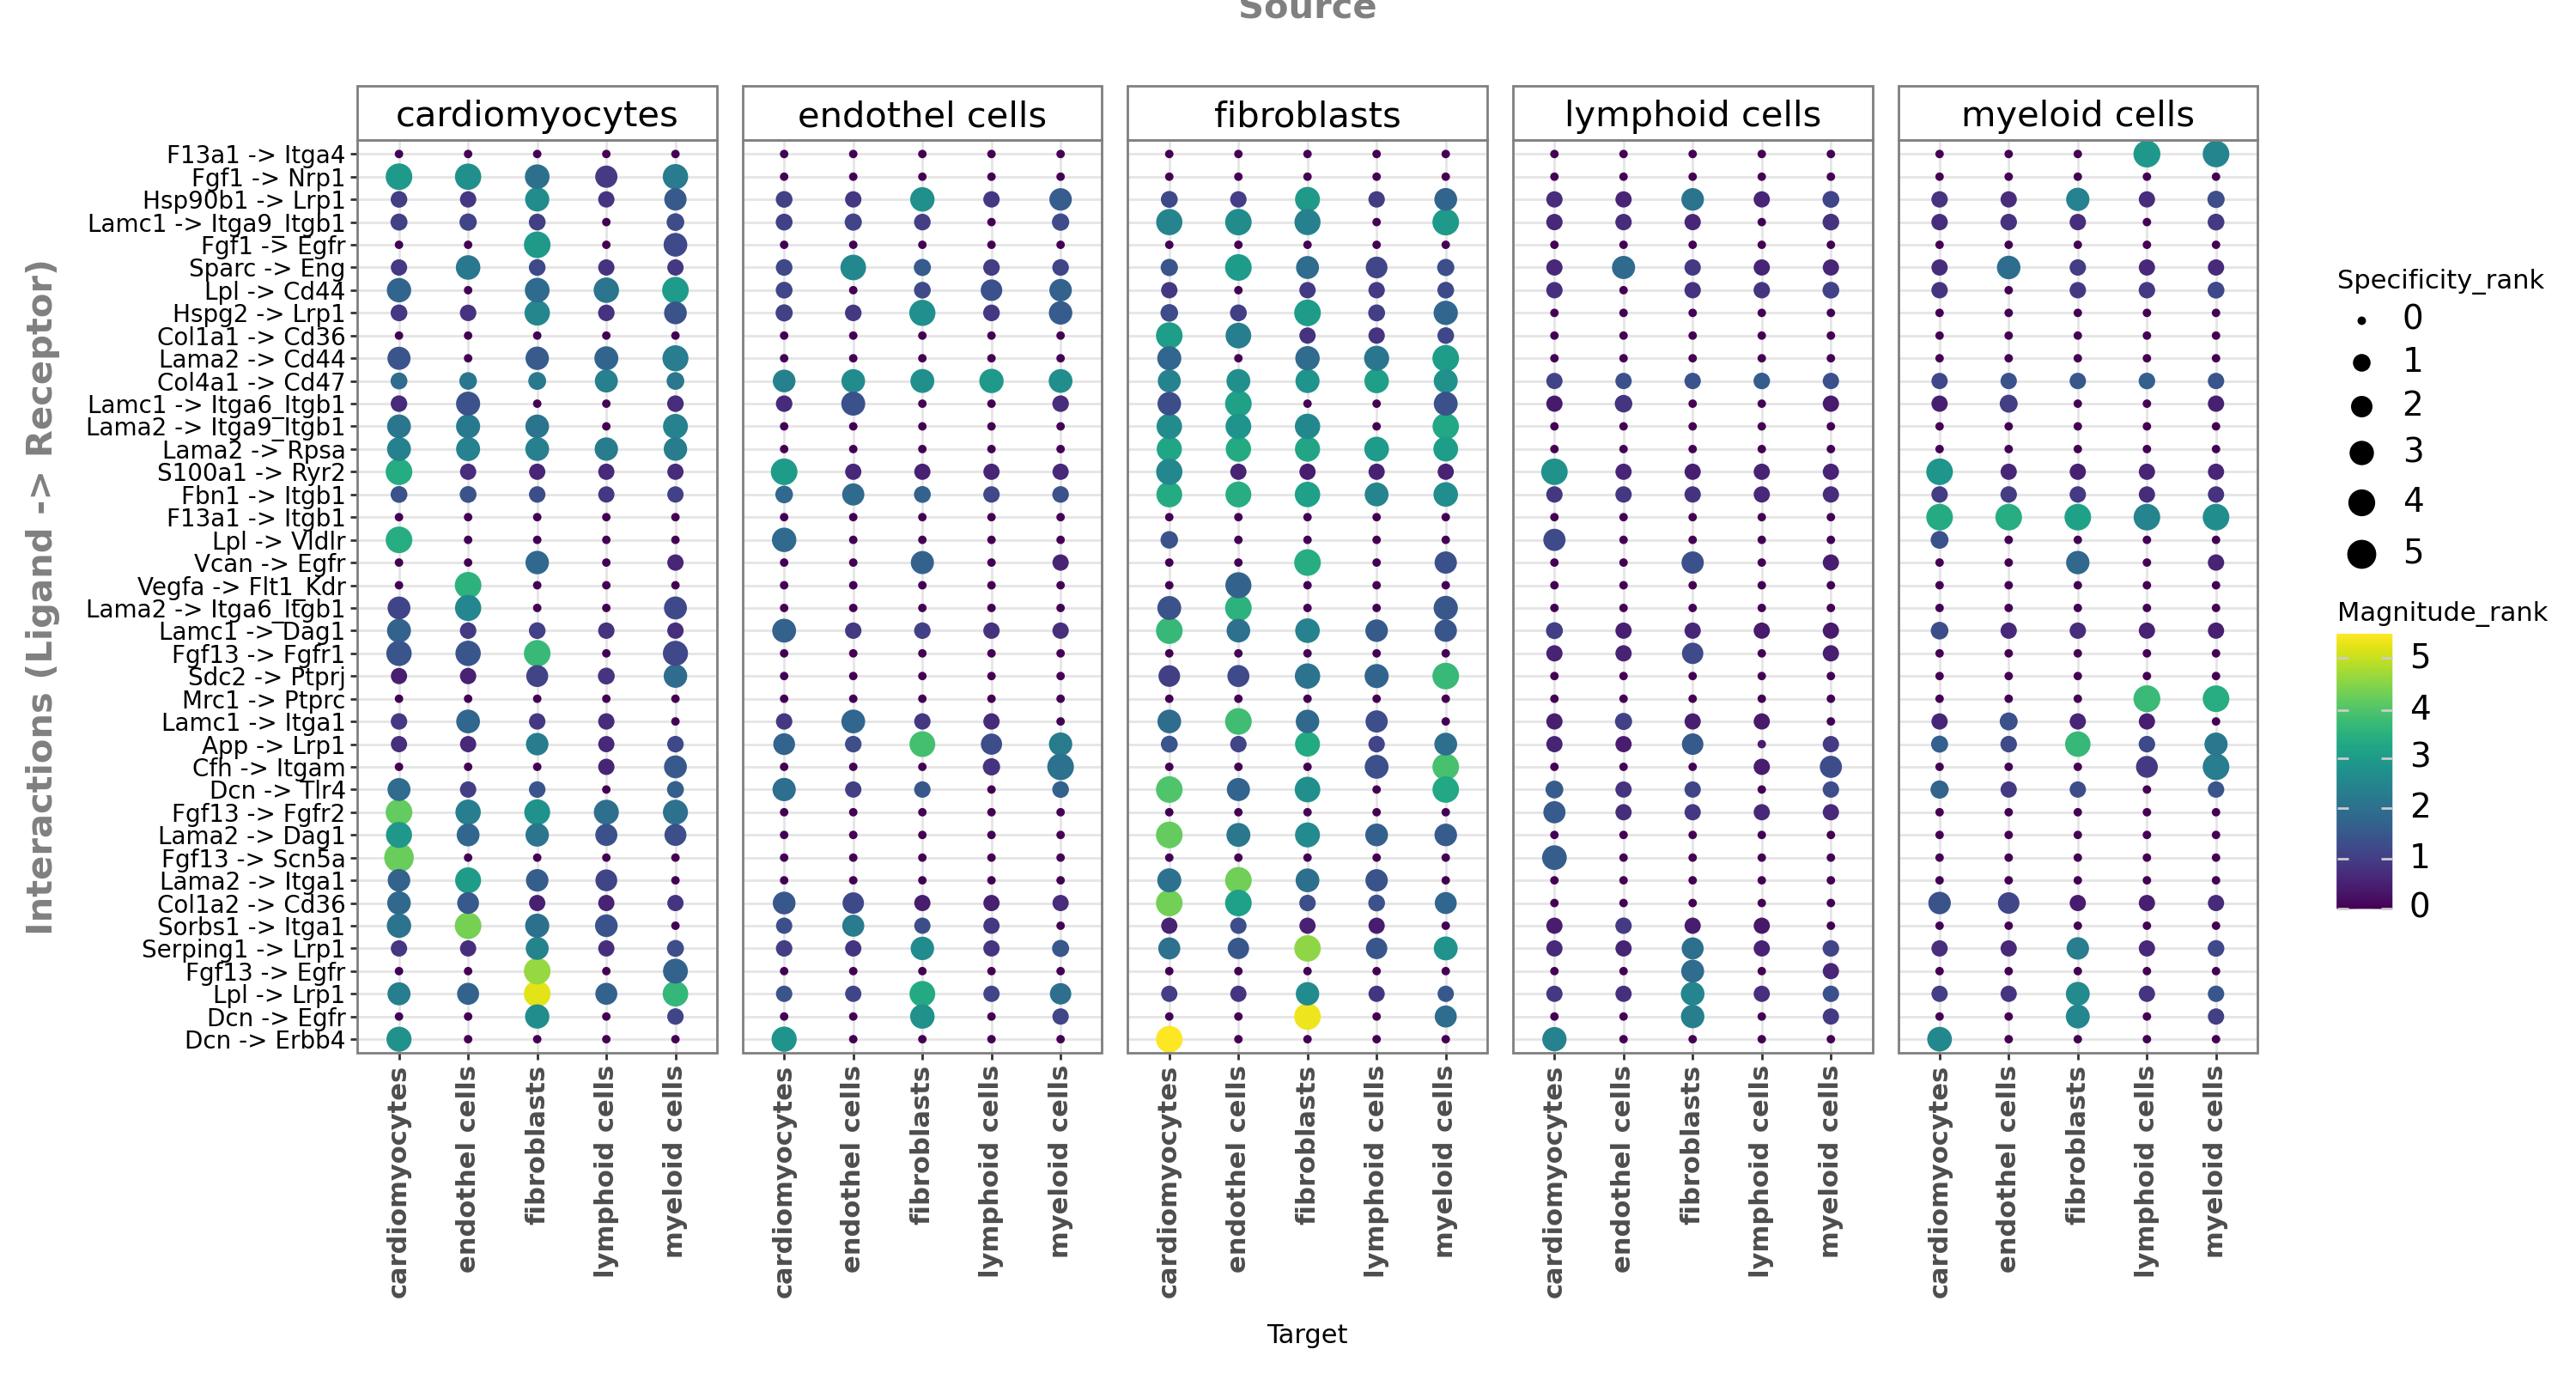

In [32]:
li.pl.dotplot(
    adata=adata_gfp,
    colour="magnitude_rank",
    size="specificity_rank",
    inverse_colour=True,  # we inverse sign since we want small p-values to have large sizes
    inverse_size=True,
    # We choose only the cell types which we wish to plot
    source_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    target_labels=["cardiomyocytes", "myeloid cells", "lymphoid cells", "fibroblasts", "endothel cells"],
    # since the rank_aggregate can also be interpreted as a probability distribution
    # we can again filter them according to their specificity significance
    # yet here the interactions are filtered according to
    # how consistently highly-ranked is their specificity across the methods
    # filterby="specificity_rank",
    # filter_lambda=lambda x: x <= 0.05,
    filter_fun=lambda x: x["specificity_rank"] <= 0.05,
    # again, we can also further order according to magnitude
    orderby="magnitude_rank",
    orderby_ascending=True,  # prioritize those with lowest values
    top_n=40,  # and we want to keep only the top 20 interactions
    figure_size=(15, 8),
    size_range=(1, 6),
)